# # 종합 실습 가이드_ML / DL



- 실습 주제 : 의료 데이터를 활용해 환자의 1년 후 당뇨병 진행정도를 예측하는 모델 개발
- 실습 목표 : Test 데이터 기준 MAPE를 최소화하고, Feature 영향도 분석하기
- 실습 조건
  - 분석 데이타 : 아래 URL link 데이타를 사용
  - Target 변수 : target (당뇨 진행 정도: 값이 클수록 당뇨 진행정도가 높음). *Target 변수는 어떠한 데이타 변환도 하지 않음
  - 학습 조건 : 아래 Baseline Code 를 참고하여 (필수) 과정인 데이터 분할 및 Feature Engineering(데이터 변환 포함) 과정은 **아래 제시된 코드를 그대로 사용**하고, 학습 및 평가 단계에서 **모델의 종류와 하이퍼파라미터 값만 자율적으로 선택**
  - 데이타 건수 : 데이타 제거는 하지 않음 (전체/Train/Test 건수 그대로 유지), 중복 데이타가 있어도 제거하지 않음
- 실습 과제  
Q1) ML or DL 모델을 활용하여 Test 데이터 기준 MAPE를 최소화 하는 모델과 Hyperparameter 찾기. *조건 : Hyperparameter 자동 최적화 기법은 사용하지 않음   
Q2) Tree 시각화에서 당뇨 진행정도가 가장 높은 집단과 가장 낮은 집단의 규칙(Rule)을 도출하기. *조건: Tree 깊이는 max_depth=3 로 하고 그외 Hyperparameter 값은 자율적으로 선택, Scaling 된 상태에서 Rule 생성  
Q3) Random Forest 기준 특성 중요도(Feature Importance) 분석 결과 1~3위 Feature 찾기. *조건: Hyperparameter 값은 자율적으로 선택
- 실습 제출물
   - 종합실습_결과물_ML_DL_OOO.xlsx 에 실습 결과 작성 후 코드 (.ipynb)와 같이 제출   
   - 실습 결과는 제출 코드로 재현이 가능해야 함
   - 제출시 화일명은 본인 이름으로 2개 화일 제출 (엑셀, 코드)   
     예) **종합실습_결과물_ML_DL_홍길동.xlsx, 종합실습_결과물_ML_DL_홍길동.ipynb**
- [참고] 데이타 설명 : 당뇨병 환자의 건강 정보를 이용하여 1년 후 질병 진행 정도를 예측하는 표준화된 데이터셋
| 컬럼명    | 한글명           | 의미                            | 비고               |
| ------ | ------------- | ----------------------------- | ---------------- |
| age    | 나이            | 환자의 연령                        | 연속형              |
| sex    | 성별            | 환자의 성별                        | 연속형             |
| bmi    | 체질량지수(BMI)    | Body Mass Index               | 연속형              |
| bp     | 평균 혈압         | Average Blood Pressure        | 연속형              |
| s1     | 총 콜레스테롤       | Total Serum Cholesterol       | 연속형              |
| s2     | LDL           | 저밀도 지단백(LDL)                  | 연속형              |
| s3     | HDL           | 고밀도 지단백(HDL)                  | 연속형              |
| s4     | 총콜레스테롤/HDL 비율 | Total Cholesterol / HDL Ratio | 연속형              |
| s5     | 혈청 중성지방       | Serum Triglycerides           | 연속형              |
| s6     | 혈당            | Blood Glucose                 | 연속형              |
| target | 질병 진행 정도      | 1년 후 당뇨병 진행 정도를 나타내는 연속형 점수   | **종속변수(Target)** |


# Baseline Code
데이타 불러오기 **(필수)**

In [1]:

import sklearn
import xgboost
import lightgbm
import pandas
import numpy
import matplotlib
import tensorflow

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("TensorFlow:", tensorflow.__version__)
print("설치 완료")

scikit-learn: 1.9.0
XGBoost: 3.4.1
LightGBM: 4.7.0
TensorFlow: 2.20.0
설치 완료


In [2]:
# ================================
# Random Seed 고정
# ================================

import tensorflow as tf

# Python, NumPy, TensorFlow Seed를 한 번에 설정
SEED = 42
tf.keras.utils.set_random_seed(SEED)


# ================================
# 데이타 불러오기
# ================================

import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


데이타 분할 및 Feature Engineering **(필수)**

In [4]:
# ================================
# 데이타 분할
# ================================

from sklearn.model_selection import train_test_split

# X, y 분리
X = df.drop('target', axis=1)
y = df['target']

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ================================
# Misssing 처리
# ================================

# === 연속형 처리 ===

import numpy as np
import pandas as pd

# 연속형 변수 선택
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Train 기준 중앙값 계산
median_values = X_train[num_cols].median()

# Train, Test 모두 Train 기준 중앙값으로 대체
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)


# ================================
# Scaling 처리
# ================================

# Min-Max Scaling

from sklearn.preprocessing import MinMaxScaler

# 연속형 변수 추출
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Min-Max Scaling
scaler = MinMaxScaler()

# Train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

 # Test
X_test[num_cols] = scaler.transform(X_test[num_cols])

학습 및 평가

In [5]:
# ================================
# 의사결정나무
# ================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = DecisionTreeRegressor(
    max_depth=3,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"\n=== DecisionTreeRegressor ===")
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")


=== DecisionTreeRegressor ===
Train MAPE: 39.392
Test  MAPE: 42.511


# Q1. 여러 모델 수동 비교

In [6]:
import time
import pandas as pd

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# 자동 최적화가 아니라 직접 선정한 모델 후보
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=5,
        loss="huber",
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=2,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.02,
        num_leaves=7,
        max_depth=3,
        min_child_samples=15,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}


results = []
trained_models = {}

for name, model in models.items():
    start_time = time.perf_counter()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    execution_time = time.perf_counter() - start_time

    train_mape = (
        mean_absolute_percentage_error(y_train, train_pred) * 100
    )
    test_mape = (
        mean_absolute_percentage_error(y_test, test_pred) * 100
    )

    results.append({
        "Model": name,
        "Train MAPE (%)": train_mape,
        "Test MAPE (%)": test_mape,
        "Execution Time (sec)": execution_time
    })

    trained_models[name] = model


result_df = pd.DataFrame(results)
result_df = result_df.sort_values("Test MAPE (%)").reset_index(drop=True)

display(result_df.round(3))

,Model,Train MAPE (%),Test MAPE (%),Execution Time (sec)
0,LightGBM,26.014,36.070,1.224
1,XGBoost,29.364,36.382,0.645
2,Extra Trees,13.089,37.089,1.664
3,Gradient Boosting,29.585,37.309,1.584
4,Random Forest,18.514,38.000,3.407


In [7]:
best_model_name = result_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

best_train_mape = result_df.loc[0, "Train MAPE (%)"]
best_test_mape = result_df.loc[0, "Test MAPE (%)"]

print("=== Q1 최종 결과 ===")
print(f"최종 모델      : {best_model_name}")
print(f"Train MAPE     : {best_train_mape:.3f}%")
print(f"Test MAPE      : {best_test_mape:.3f}%")
print(f"Hyperparameter : {best_model.get_params()}")

=== Q1 최종 결과 ===
최종 모델      : LightGBM
Train MAPE     : 26.014%
Test MAPE      : 36.070%
Hyperparameter : {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.8, 'importance_type': 'split', 'learning_rate': 0.02, 'max_depth': 3, 'min_child_samples': 15, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': -1, 'num_leaves': 7, 'objective': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}


# Q2. 의사결정나무 시각화 및 규칙 추출

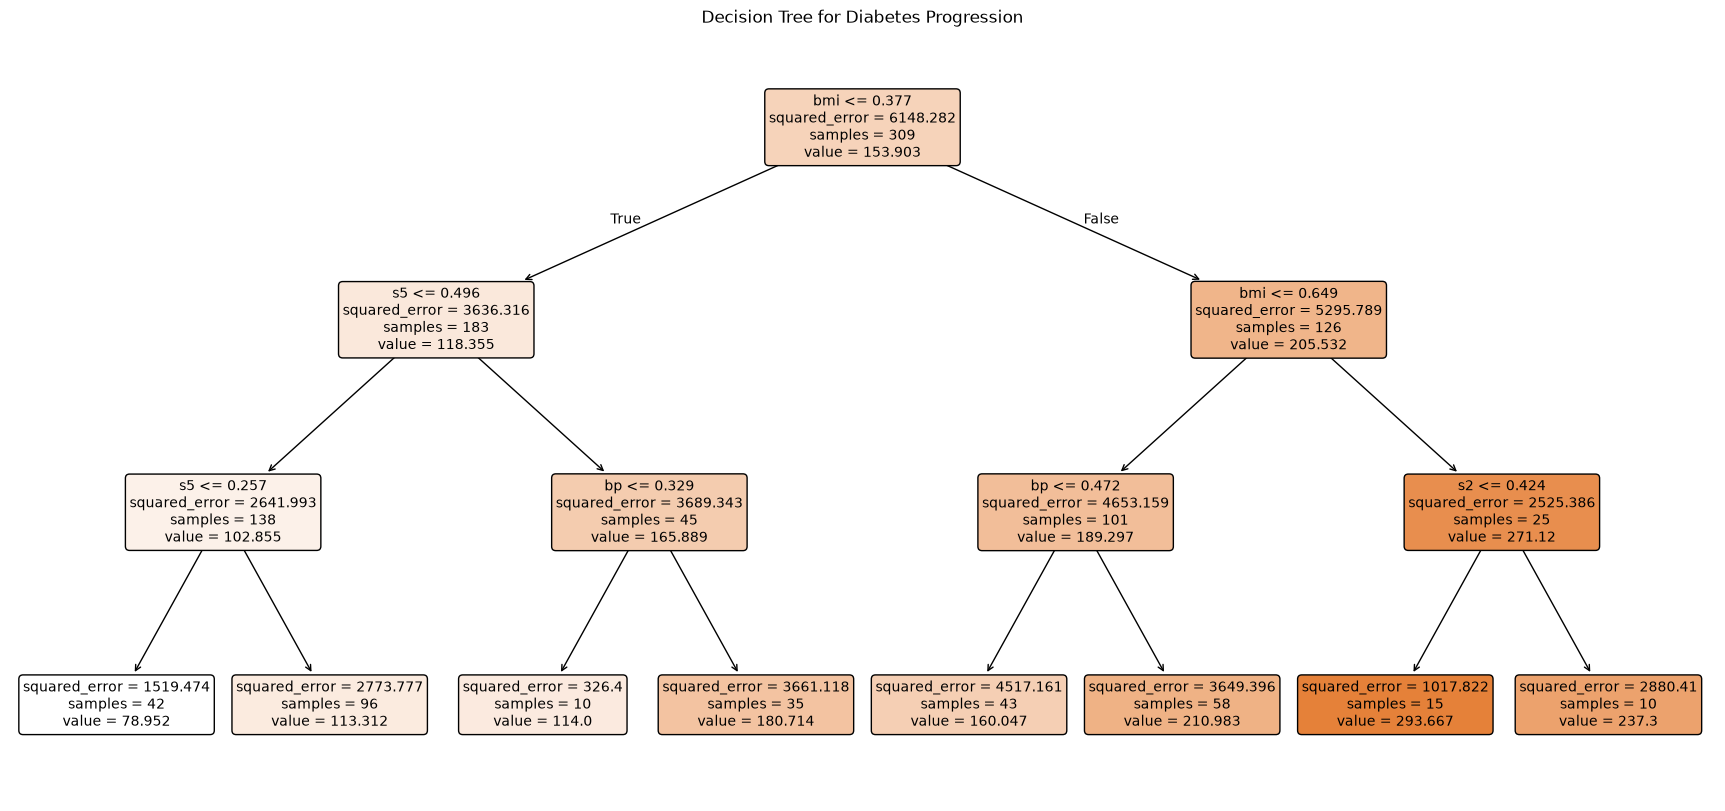

In [8]:
import matplotlib.pyplot as plt

from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree,
    _tree
)


tree_model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    precision=3,
    fontsize=10
)

plt.title("Decision Tree for Diabetes Progression")
plt.show()

In [9]:
def extract_leaf_rules(model, feature_names):
    tree = model.tree_
    rules = []

    def traverse(node, conditions):
        # 분기 노드
        if tree.feature[node] != _tree.TREE_UNDEFINED:
            feature = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]

            traverse(
                tree.children_left[node],
                conditions + [f"{feature} <= {threshold:.3f}"]
            )

            traverse(
                tree.children_right[node],
                conditions + [f"{feature} > {threshold:.3f}"]
            )

        # 리프 노드
        else:
            rules.append({
                "node": node,
                "prediction": float(tree.value[node].squeeze()),
                "samples": int(tree.n_node_samples[node]),
                "rule": " AND ".join(conditions)
            })

    traverse(0, [])
    return pd.DataFrame(rules)


leaf_rules = extract_leaf_rules(
    tree_model,
    X_train.columns.tolist()
)

leaf_rules = leaf_rules.sort_values(
    "prediction",
    ascending=False
).reset_index(drop=True)

display(leaf_rules)

,node,prediction,samples,rule
0,13,293.666667,15,bmi > 0.377 AND bmi > 0.649 AND s2 <= 0.424
1,14,237.300000,10,bmi > 0.377 AND bmi > 0.649 AND s2 > 0.424
2,11,210.982759,58,bmi > 0.377 AND bmi <= 0.649 AND bp > 0.472
3,7,180.714286,35,bmi <= 0.377 AND s5 > 0.496 AND bp > 0.329
4,10,160.046512,43,bmi > 0.377 AND bmi <= 0.649 AND bp <= 0.472
5,6,114.000000,10,bmi <= 0.377 AND s5 > 0.496 AND bp <= 0.329
6,4,113.312500,96,bmi <= 0.377 AND s5 <= 0.496 AND s5 > 0.257
7,3,78.952381,42,bmi <= 0.377 AND s5 <= 0.496 AND s5 <= 0.257


In [10]:
highest_group = leaf_rules.iloc[0]
lowest_group = leaf_rules.iloc[-1]

print("=== Q2 가장 높은 집단 ===")
print(f"예측 진행 정도 : {highest_group['prediction']:.3f}")
print(f"학습 데이터 수 : {highest_group['samples']}")
print(f"규칙           : {highest_group['rule']}")

print("\n=== Q2 가장 낮은 집단 ===")
print(f"예측 진행 정도 : {lowest_group['prediction']:.3f}")
print(f"학습 데이터 수 : {lowest_group['samples']}")
print(f"규칙           : {lowest_group['rule']}")

=== Q2 가장 높은 집단 ===
예측 진행 정도 : 293.667
학습 데이터 수 : 15
규칙           : bmi > 0.377 AND bmi > 0.649 AND s2 <= 0.424

=== Q2 가장 낮은 집단 ===
예측 진행 정도 : 78.952
학습 데이터 수 : 42
규칙           : bmi <= 0.377 AND s5 <= 0.496 AND s5 <= 0.257


# Q3. Random Forest 특성 중요도

In [11]:
rf_q3 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

rf_q3.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_q3.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,bmi,0.366884
1,s5,0.201271
2,bp,0.110124
3,s6,0.066777
4,s3,0.058895
5,age,0.053508
6,s2,0.052414
7,s1,0.049278
8,s4,0.029869
9,sex,0.010978


In [12]:
top3 = feature_importance.head(3)

print("=== Q3 Feature Importance ===")

for index, row in top3.iterrows():
    print(
        f"{index + 1}위: {row['Feature']} "
        f"(중요도: {row['Importance']:.4f})"
    )

=== Q3 Feature Importance ===
1위: bmi (중요도: 0.3669)
2위: s5 (중요도: 0.2013)
3위: bp (중요도: 0.1101)


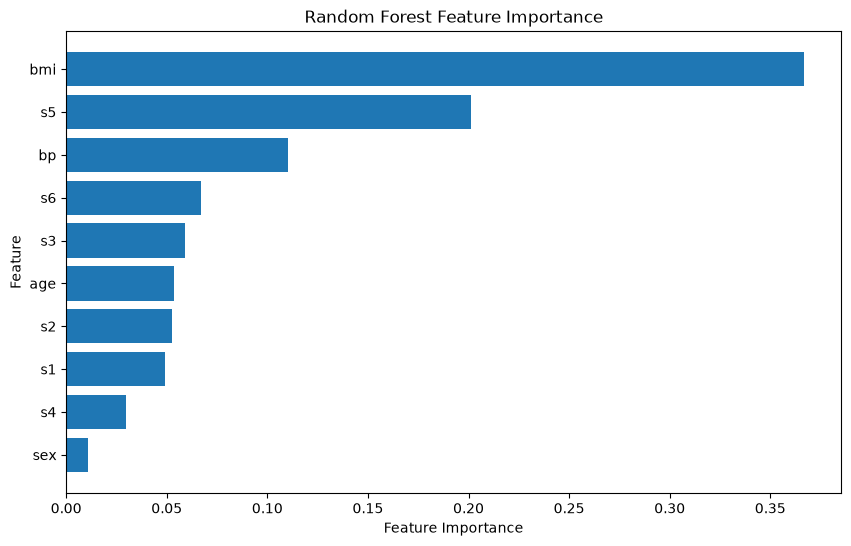

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()